In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset - correct path
fake = pd.read_csv('C:/Users/yasha/OneDrive/Desktop/fake-news-detection/data/raw/Fake.csv')
true = pd.read_csv('C:/Users/yasha/OneDrive/Desktop/fake-news-detection/data/raw/True.csv')

# Check shape
print("Fake news shape:", fake.shape)
print("True news shape:", true.shape)

# Check columns
print("\nColumns:", fake.columns.tolist())

# First 5 rows
fake.head()

Fake news shape: (23481, 4)
True news shape: (21417, 4)

Columns: ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [2]:
# Add label column
fake['label'] = 0  # 0 = Fake
true['label'] = 1  # 1 = True

# Combine both datasets
df = pd.concat([fake, true], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())

# Check null values
print("\nNull values:")
print(df.isnull().sum())

Combined dataset shape: (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Null values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/yasha/OneDrive/Desktop/fake-news-detection/screenshots/distribution.png'

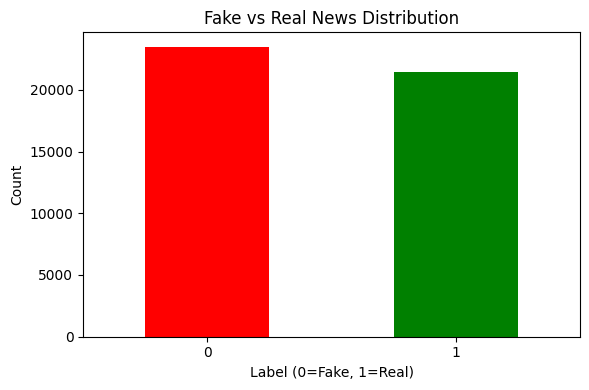

In [3]:
# Visualize label distribution
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', 
                                 color=['red', 'green'])
plt.title('Fake vs Real News Distribution')
plt.xlabel('Label (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('C:/Users/yasha/OneDrive/Desktop/fake-news-detection/screenshots/distribution.png')
plt.show()

In [4]:
# Text length analysis
df['text_length'] = df['text'].apply(len)

print("Average text length:")
print(df.groupby('label')['text_length'].mean())

# Sample text
print("\nSample Fake News:")
print(df[df['label']==0]['text'].iloc[0][:200])

print("\nSample Real News:")
print(df[df['label']==1]['text'].iloc[0][:200])

Average text length:
label
0    2547.396235
1    2383.278517
Name: text_length, dtype: float64

Sample Fake News:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former rea

Sample Real News:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 


In [5]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove stopwords and stem
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)
print("Preprocessing complete!")
print(df['clean_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yasha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yasha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Preprocessing complete!
donald trump wish american happi new year leav instead give shout enemi hater dishonest fake news media former realiti show star one job countri rapidli grow stronger smarter want wish friend support 


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train test split
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (35918,)
Test size: (8980,)


In [7]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Model training complete!")

# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

TF-IDF shape: (35918, 5000)
Model training complete!

Accuracy: 98.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4733
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [8]:
import joblib

# Save model and vectorizer
joblib.dump(model, 'C:/Users/yasha/OneDrive/Desktop/fake-news-detection/models/fake_news_model.pkl')
joblib.dump(tfidf, 'C:/Users/yasha/OneDrive/Desktop/fake-news-detection/models/vectorizer.pkl')

print("✅ Model saved successfully!")
print("✅ Vectorizer saved successfully!")

✅ Model saved successfully!
✅ Vectorizer saved successfully!
